# ch304 — Forward Pass

## 1. From single samples to batches

In ch303 the forward pass operated on a single input vector $x \in \mathbb{R}^{n_0}$.
In practice, we process $B$ samples simultaneously — a **batch** — to exploit vectorised
hardware (GPU SIMD units). The computation becomes:

$$
Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}
$$

where $A^{[l-1]} \in \mathbb{R}^{n_{l-1} \times B}$ holds $B$ column vectors,
$Z^{[l]} \in \mathbb{R}^{n_l \times B}$, and $b^{[l]}$ broadcasts over the batch dimension.

The entire batch processes in one matrix multiplication — orders of magnitude faster than
a Python loop over samples.

*(Broadcasting mechanics from NumPy: ch147. Matrix multiplication: ch153.)*

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt


def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, z)


def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def forward_pass_batched(X: np.ndarray, params: list, activations: list) -> tuple:
    """
    Batched forward pass.

    Parameters
    ----------
    X : ndarray, shape (n_features, batch_size)
    params : list of (W, b) tuples per layer
    activations : list of activation functions (one per layer)

    Returns
    -------
    output : final layer activations, shape (n_out, batch_size)
    cache  : list of (A_prev, Z, A) per layer — needed for backprop
    """
    cache = []
    A = X
    for (W, b), act_fn in zip(params, activations):
        A_prev = A
        # b[:, None] broadcasts bias over all B samples in the batch
        Z = W @ A + b[:, None]
        A = act_fn(Z)
        cache.append((A_prev, Z, A))
    return A, cache


# --- Build a small network and time batched vs loop ---
rng = np.random.default_rng(42)
layer_sizes = [784, 256, 128, 10]   # MNIST-like architecture

params = []
for i in range(len(layer_sizes) - 1):
    fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
    scale = np.sqrt(2.0 / fan_in)  # He initialisation — see ch308
    W = rng.normal(0, scale, (fan_out, fan_in))
    b = np.zeros(fan_out)
    params.append((W, b))

act_fns = [relu, relu, sigmoid]

# Batched: (784, 256) input
B = 256
X_batch = rng.normal(0, 1, (784, B))

t0 = time.perf_counter()
out_batch, cache = forward_pass_batched(X_batch, params, act_fns)
t_batch = time.perf_counter() - t0

# Loop: one sample at a time
t0 = time.perf_counter()
outs = []
for i in range(B):
    out_i, _ = forward_pass_batched(X_batch[:, i:i+1], params, act_fns)
    outs.append(out_i)
t_loop = time.perf_counter() - t0

print(f"Input shape:  {X_batch.shape}")
print(f"Output shape: {out_batch.shape}")
print(f"\nBatched forward pass:  {t_batch*1000:.2f} ms")
print(f"Loop forward pass:     {t_loop*1000:.2f} ms")
print(f"Speedup:               {t_loop/t_batch:.1f}x")

# Verify equivalence
out_loop_stacked = np.hstack(outs)
print(f"\nMax absolute difference (batched vs loop): {np.max(np.abs(out_batch - out_loop_stacked)):.2e}")

Input shape:  (784, 256)
Output shape: (10, 256)

Batched forward pass:  6.28 ms
Loop forward pass:     35.85 ms
Speedup:               5.7x

Max absolute difference (batched vs loop): 7.77e-16


Cache contents (needed by backpropagation in ch306):
  Layer 1: A_prev (784, 256), Z (256, 256), A (256, 256)
  Layer 2: A_prev (256, 256), Z (128, 256), A (128, 256)
  Layer 3: A_prev (128, 256), Z (10, 256), A (10, 256)


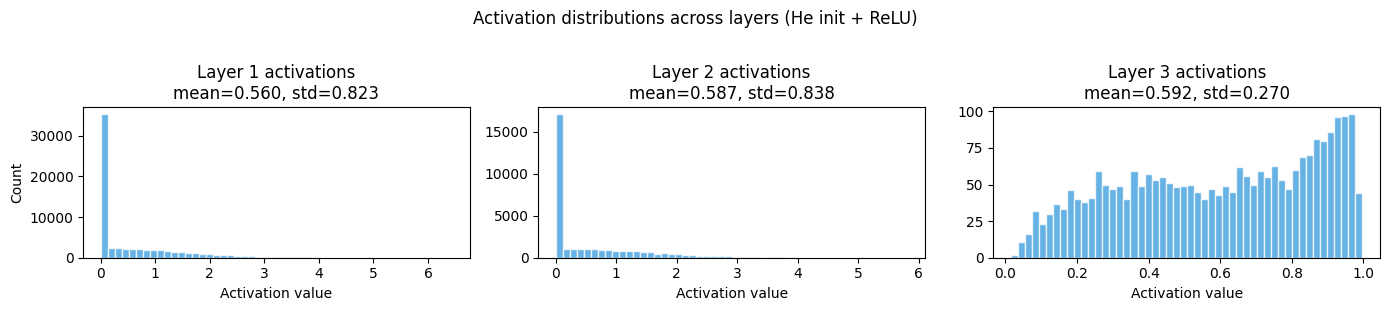


Healthy signs: roughly stable std across layers.
Unhealthy: std collapsing to 0 (vanishing) or exploding to >10 (exploding gradients).


In [2]:
# Inspect the cache — what gets stored for backprop
print("Cache contents (needed by backpropagation in ch306):")
for l, (A_prev, Z, A) in enumerate(cache):
    print(f"  Layer {l+1}: A_prev {A_prev.shape}, Z {Z.shape}, A {A.shape}")

# Activation statistics (healthy forward pass diagnostics)
fig, axes = plt.subplots(1, len(cache), figsize=(14, 3))
for l, (_, Z, A) in enumerate(cache):
    ax = axes[l]
    ax.hist(A.ravel(), bins=50, color='#3498db', alpha=0.75, edgecolor='white')
    ax.set_title(f'Layer {l+1} activations\nmean={A.mean():.3f}, std={A.std():.3f}')
    ax.set_xlabel('Activation value')
    if l == 0:
        ax.set_ylabel('Count')
plt.suptitle('Activation distributions across layers (He init + ReLU)', y=1.02)
plt.tight_layout()
plt.savefig('ch304_activations.png', dpi=120)
plt.show()

print("\nHealthy signs: roughly stable std across layers.")
print("Unhealthy: std collapsing to 0 (vanishing) or exploding to >10 (exploding gradients).")

## 2. Shape accounting — the discipline of forward passes

The single most common source of errors in implementing networks is shape mismatches.
Every tensor in the forward pass has a precise shape. Track them explicitly:

| Layer | Operation | Input shape | Weight shape | Output shape |
|-------|-----------|-------------|--------------|-------------|
| 1 | Linear | $(784, B)$ | $(256, 784)$ | $(256, B)$ |
| 1 | ReLU | $(256, B)$ | — | $(256, B)$ |
| 2 | Linear | $(256, B)$ | $(128, 256)$ | $(128, B)$ |
| 2 | ReLU | $(128, B)$ | — | $(128, B)$ |
| 3 | Linear | $(128, B)$ | $(10, 128)$ | $(10, B)$ |
| 3 | Sigmoid | $(10, B)$ | — | $(10, B)$ |

**Rule:** $W^{[l]}$ has shape $(n_l, n_{l-1})$. Multiplying $W^{[l]} @ A^{[l-1]}$
contracts the $n_{l-1}$ dimension. The batch dimension $B$ is never touched by the weights.

---

## 3. The cache: why we store intermediate values

The cache stores $(A^{[l-1]}, Z^{[l]}, A^{[l]})$ for every layer. During the backward pass
*(ch306)*:
- $A^{[l-1]}$ is needed to compute $\partial \mathcal{L} / \partial W^{[l]}$
- $Z^{[l]}$ is needed to compute the derivative of the activation $\sigma'(Z^{[l]})$

Memory usage scales as $O(L \cdot B \cdot \max_l n_l)$. For large models and large batches,
this becomes the primary memory constraint — not the parameter count.

---

## 4. Numerical considerations

The forward pass is where numerical problems originate:

- **Overflow in sigmoid:** `exp(-z)` for very negative `z` and `exp(z)` for very positive `z`.
  Fix: clip $z$ before exponentiation, or use log-sum-exp tricks.
- **Dead ReLU:** if `z` is always negative, `relu(z) = 0` permanently.
  The gradient of ReLU is zero for negative inputs, so the neuron cannot recover.
  Fix: He initialisation *(ch308)*, careful learning rate.
- **Activation saturation:** sigmoid/tanh squash large inputs to flat regions where gradient ≈ 0.
  Fix: use ReLU variants in hidden layers.

---

## 5. Summary

- The forward pass processes a full batch in one matrix operation per layer.
- Shape tracking is mandatory: $W^{[l]}$ maps $(n_{l-1}, B)$ to $(n_l, B)$.
- The cache stores intermediate activations for use during backpropagation.
- Numerical stability requires careful handling of activations and initialisations.

---

## 6. Forward and backward references

**Used here:** matrix multiplication shapes *(ch153–ch155)*, broadcasting *(ch147)*,
activation functions *(ch064–065)*, multilayer structure *(ch303)*.

**This will reappear in ch306 — Backpropagation from Scratch**, where the cache built here
is consumed in reverse to compute every gradient needed for parameter updates.